# Análise de Leitos Hospitalares CNES - Foco em Santos (SP)

Este notebook foi estruturado para uma apresentação executiva e técnica da capacidade hospitalar, com foco na região de **Santos**.

Objetivos:
- Entender o perfil da oferta de leitos e UTI;
- Medir cobertura SUS e concentração da oferta;
- Comparar Santos com São Paulo e Brasil;
- Apontar riscos e oportunidades de gestão pública em saúde.

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib

# Fallback para execução fora do Jupyter (evita erro de backend Tk)
if 'ipykernel' not in sys.modules:
    matplotlib.use('Agg')

import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid', context='talk')
except Exception:
    sns = None
    plt.style.use('ggplot')

pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

In [2]:
# Carga da base
arquivo = 'hospitais CNES.xlsx'
abas = pd.ExcelFile(arquivo).sheet_names
print('Abas disponiveis:', abas)

aba_principal = 'Leitos_2026' if 'Leitos_2026' in abas else abas[0]
df = pd.read_excel(arquivo, sheet_name=aba_principal)
print('Aba utilizada:', aba_principal)
print('Shape:', df.shape)
df.head(3)

Abas disponiveis: ['Leitos_2026', 'hospitais CNES']
Aba utilizada: Leitos_2026
Shape: (21602, 35)


,COMP,REGIAO,UF,CO_IBGE,MUNICIPIO,MOTIVO_DESABILITACAO,CNES,NOME_ESTABELECIMENTO,RAZAO_SOCIAL,TP_GESTAO,CO_TIPO_UNIDADE,DS_TIPO_UNIDADE,NATUREZA_JURIDICA,DESC_NATUREZA_JURIDICA,NO_LOGRADOURO,NU_ENDERECO,NO_COMPLEMENTO,NO_BAIRRO,CO_CEP,NU_TELEFONE,NO_EMAIL,LEITOS_EXISTENTES,LEITOS_SUS,UTI_TOTAL_EXIST,UTI_TOTAL_SUS,UTI_ADULTO_EXIST,UTI_ADULTO_SUS,UTI_PEDIATRICO_EXIST,UTI_PEDIATRICO_SUS,UTI_NEONATAL_EXIST,UTI_NEONATAL_SUS,UTI_QUEIMADO_EXIST,UTI_QUEIMADO_SUS,UTI_CORONARIANA_EXIST,UTI_CORONARIANA_SUS
0,202601,NORDESTE,PE,260290,CABO DE SANTO AGOSTINHO,NaN,27,CASA DE SAUDE SANTA HELENA,CASA DE SAUDE E MATERNIDADE SANTA HELENA LTDA,M,5,HOSPITAL GERAL,2062,HOSPITAL_PRIVADO,AVN PRESIDENTE GETULIO VARGAS,428,NaN,CENTRO,54505560,(81)35210355,NaN,64,0,0,0,0,0,0,0,0,0,0,0,0,0
1,202601,NORDESTE,PE,260290,CABO DE SANTO AGOSTINHO,NaN,35,HOSPITAL MENDO SAMPAIO,PREFEITURA MUNICIPAL DO CABO DE SANTO AGOSTINHO,M,5,HOSPITAL GERAL,1244,HOSPITAL_PÚBLICO,BR 101 SUL KM 33,S/N,NaN,CHARNECA,54535430,(81)35210857,NaN,29,29,0,0,0,0,0,0,0,0,0,0,0,0
2,202601,NORDESTE,PE,260290,CABO DE SANTO AGOSTINHO,NaN,94,MATERNIDADE PADRE GERALDO LEITE BASTOS,PREFEITURA MUNICIPAL DO CABO DE SANTO AGOSTINHO,M,7,HOSPITAL ESPECIALIZADO,1244,HOSPITAL_PÚBLICO,BR 101 SUL KM 23,S/N,NaN,PONTE DOS CARVALHOS,54510000,(81)35221626,NaN,18,18,0,0,0,0,0,0,0,0,0,0,0,0


## Metodologia

- A coluna `COMP` representa a competência temporal (ex.: `202601`, `202602`, `202603`).
- Para **fotografia atual** da rede, usamos a **competência mais recente**.
- Para **evolução temporal**, usamos todas as competências.
- Filtro de Santos é feito com normalização de texto para evitar problemas de acentuação.
- Indicadores-chave:
  - `pct_sus_leitos = LEITOS_SUS / LEITOS_EXISTENTES`
  - `pct_sus_uti = UTI_TOTAL_SUS / UTI_TOTAL_EXIST`
  - `pct_uti_sobre_leitos = UTI_TOTAL_EXIST / LEITOS_EXISTENTES`

In [3]:
# Qualidade dos dados
colunas_numericas = [
    'LEITOS_EXISTENTES','LEITOS_SUS','UTI_TOTAL_EXIST','UTI_TOTAL_SUS',
    'UTI_ADULTO_EXIST','UTI_ADULTO_SUS','UTI_PEDIATRICO_EXIST','UTI_PEDIATRICO_SUS',
    'UTI_NEONATAL_EXIST','UTI_NEONATAL_SUS','UTI_QUEIMADO_EXIST','UTI_QUEIMADO_SUS',
    'UTI_CORONARIANA_EXIST','UTI_CORONARIANA_SUS'
]

qa = pd.DataFrame({
    'nulos_%': df[colunas_numericas].isna().mean() * 100,
    'negativos': (df[colunas_numericas] < 0).sum(),
    'zeros_%': (df[colunas_numericas] == 0).mean() * 100
}).sort_values('zeros_%', ascending=False)

print('Competências disponíveis:', sorted(df['COMP'].unique()))
print('Duplicidade total de linhas:', df.duplicated().sum())
qa

Competências disponíveis: [202601, 202602, 202603]
Duplicidade total de linhas: 0


,nulos_%,negativos,zeros_%
UTI_QUEIMADO_SUS,0.00,0,99.51
UTI_QUEIMADO_EXIST,0.00,0,99.27
UTI_CORONARIANA_SUS,0.00,0,99.00
UTI_CORONARIANA_EXIST,0.00,0,97.41
UTI_PEDIATRICO_SUS,0.00,0,94.35
UTI_NEONATAL_SUS,0.00,0,93.40
UTI_PEDIATRICO_EXIST,0.00,0,89.59
UTI_NEONATAL_EXIST,0.00,0,87.88
UTI_ADULTO_SUS,0.00,0,82.61
UTI_TOTAL_SUS,0.00,0,80.96


In [4]:
# Preparação de recortes

def normaliza_texto(s):
    return (s.astype(str)
              .str.upper()
              .str.normalize('NFKD')
              .str.encode('ascii', errors='ignore')
              .str.decode('ascii'))

for c in ['MUNICIPIO', 'NO_BAIRRO', 'NOME_ESTABELECIMENTO', 'DS_TIPO_UNIDADE', 'UF', 'REGIAO']:
    if c in df.columns:
        df[c + '_NORM'] = normaliza_texto(df[c])

In [5]:
# Resumo executivo Santos (competência mais recente)

resumo = {
    'Estabelecimentos (CNES)': df_santos_atual['CNES'].nunique(),
    'Leitos existentes': int(df_santos_atual['LEITOS_EXISTENTES'].sum()),
    'Leitos SUS': int(df_santos_atual['LEITOS_SUS'].sum()),
    'UTI total existente': int(df_santos_atual['UTI_TOTAL_EXIST'].sum()),
    'UTI total SUS': int(df_santos_atual['UTI_TOTAL_SUS'].sum())
}

resumo['Cobertura SUS - leitos (%)'] = 100 * resumo['Leitos SUS'] / resumo['Leitos existentes']
resumo['Cobertura SUS - UTI (%)'] = 100 * resumo['UTI total SUS'] / resumo['UTI total existente']
resumo['UTI sobre leitos (%)'] = 100 * resumo['UTI total existente'] / resumo['Leitos existentes']

pd.DataFrame(resumo, index=['Santos']).T

NameError: name 'df_santos_atual' is not defined

,COMP,LEITOS_EXISTENTES,LEITOS_SUS,UTI_TOTAL_EXIST,UTI_TOTAL_SUS,pct_sus_leitos,pct_sus_uti
0,202601,1939,804,341,143,41.46,41.94
1,202602,1939,804,341,143,41.46,41.94
2,202603,1939,814,341,143,41.98,41.94


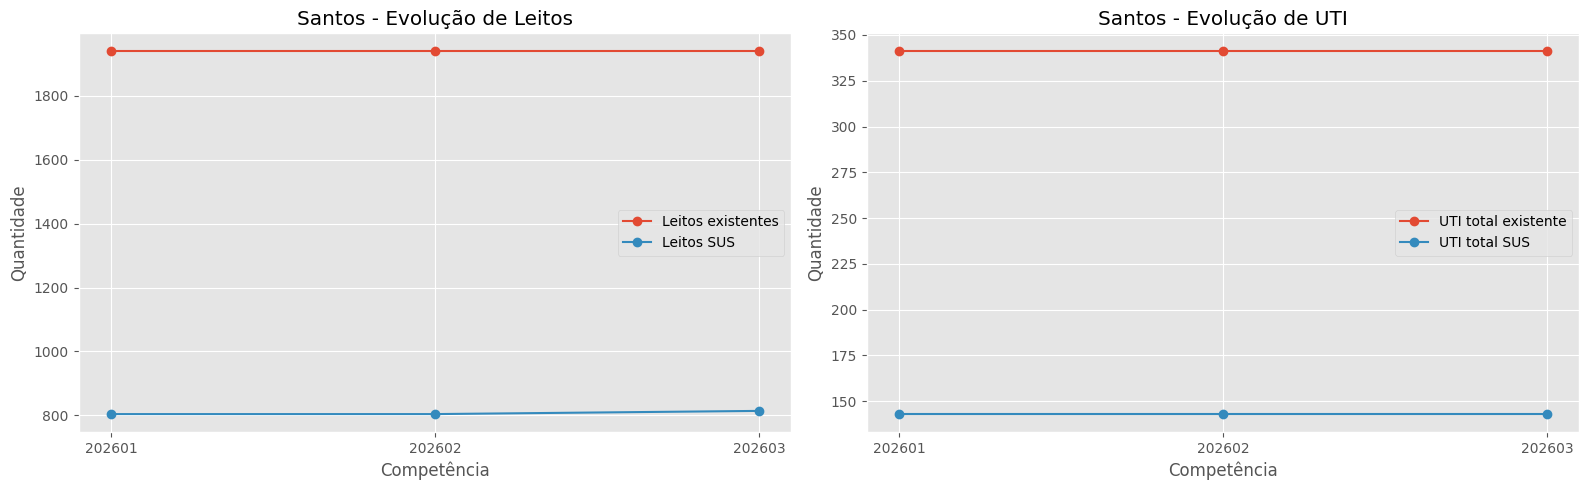

In [ ]:
# Evolução mensal em Santos (Jan/2026 a Mar/2026)

serie_santos = (df_santos
    .groupby('COMP', as_index=False)[['LEITOS_EXISTENTES','LEITOS_SUS','UTI_TOTAL_EXIST','UTI_TOTAL_SUS']]
    .sum()
    .sort_values('COMP'))

serie_santos['pct_sus_leitos'] = 100 * serie_santos['LEITOS_SUS'] / serie_santos['LEITOS_EXISTENTES']
serie_santos['pct_sus_uti'] = 100 * serie_santos['UTI_TOTAL_SUS'] / serie_santos['UTI_TOTAL_EXIST']

display(serie_santos)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
ax[0].plot(serie_santos['COMP'].astype(str), serie_santos['LEITOS_EXISTENTES'], marker='o', label='Leitos existentes')
ax[0].plot(serie_santos['COMP'].astype(str), serie_santos['LEITOS_SUS'], marker='o', label='Leitos SUS')
ax[0].set_title('Santos - Evolução de Leitos')
ax[0].set_xlabel('Competência')
ax[0].set_ylabel('Quantidade')
ax[0].legend()

ax[1].plot(serie_santos['COMP'].astype(str), serie_santos['UTI_TOTAL_EXIST'], marker='o', label='UTI total existente')
ax[1].plot(serie_santos['COMP'].astype(str), serie_santos['UTI_TOTAL_SUS'], marker='o', label='UTI total SUS')
ax[1].set_title('Santos - Evolução de UTI')
ax[1].set_xlabel('Competência')
ax[1].set_ylabel('Quantidade')
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Benchmark: Santos vs SP vs Brasil (competência atual)

def calcula_metricas(base):
    leitos_total = base['LEITOS_EXISTENTES'].sum()
    leitos_sus = base['LEITOS_SUS'].sum()
    uti_total = base['UTI_TOTAL_EXIST'].sum()
    uti_sus = base['UTI_TOTAL_SUS'].sum()

    return pd.Series({
        'Estabelecimentos': base['CNES'].nunique(),
        'Leitos existentes': leitos_total,
        'Leitos SUS': leitos_sus,
        'Cobertura SUS - leitos (%)': 100 * leitos_sus / leitos_total if leitos_total else np.nan,
        'UTI total existente': uti_total,
        'UTI total SUS': uti_sus,
        'Cobertura SUS - UTI (%)': 100 * uti_sus / uti_total if uti_total else np.nan,
        'UTI sobre leitos (%)': 100 * uti_total / leitos_total if leitos_total else np.nan
    })

base_santos = df_atual[df_atual['MUNICIPIO_NORM'] == 'SANTOS']
base_sp = df_atual[df_atual['UF_NORM'] == 'SP']
base_br = df_atual

benchmark = pd.DataFrame({
    'Santos': calcula_metricas(base_santos),
    'SP': calcula_metricas(base_sp),
    'Brasil': calcula_metricas(base_br)
}).T

benchmark

,Estabelecimentos,Leitos existentes,Leitos SUS,Cobertura SUS - leitos (%),UTI total existente,UTI total SUS,Cobertura SUS - UTI (%),UTI sobre leitos (%)
Santos,17.00,"1,939.00",814.00,41.98,341.00,143.00,41.94,17.59
SP,"1,021.00","109,559.00","61,863.00",56.47,"15,562.00","7,325.00",47.07,14.20
Brasil,"7,188.00","520,129.00","352,552.00",67.78,"63,773.00","31,970.00",50.13,12.26


In [ ]:
# Santos no ranking de cidades de SP (por leitos existentes)

rank_sp = (df_atual[df_atual['UF_NORM'] == 'SP']
           .groupby('MUNICIPIO', as_index=False)[['LEITOS_EXISTENTES','LEITOS_SUS','UTI_TOTAL_EXIST','UTI_TOTAL_SUS']]
           .sum())

rank_sp['Cobertura SUS leitos (%)'] = 100 * rank_sp['LEITOS_SUS'] / rank_sp['LEITOS_EXISTENTES']
rank_sp['UTI sobre leitos (%)'] = 100 * rank_sp['UTI_TOTAL_EXIST'] / rank_sp['LEITOS_EXISTENTES']
rank_sp = rank_sp.sort_values('LEITOS_EXISTENTES', ascending=False).reset_index(drop=True)
rank_sp['Posição SP (leitos)'] = rank_sp.index + 1

rank_sp.head(15)

rank_sp[rank_sp['MUNICIPIO'].astype(str).str.upper().str.normalize('NFKD').str.encode('ascii','ignore').str.decode('ascii') == 'SANTOS']

,MUNICIPIO,LEITOS_EXISTENTES,LEITOS_SUS,UTI_TOTAL_EXIST,UTI_TOTAL_SUS,Cobertura SUS leitos (%),UTI sobre leitos (%),Posição SP (leitos)
7,SANTOS,1939,814,341,143,41.98,17.59,8


,CNES,NOME_ESTABELECIMENTO,DS_TIPO_UNIDADE,NO_BAIRRO,LEITOS_EXISTENTES,LEITOS_SUS,UTI_TOTAL_EXIST,UTI_TOTAL_SUS,Cobertura SUS leitos (%),UTI sobre leitos (%)
1,2025752,SANTA CASA DE SANTOS,HOSPITAL GERAL,JABAQUARA,533,256,91,50,48.03,17.07
5,2079720,HOSPITAL GUILHERME ALVARO SANTOS,HOSPITAL GERAL,BOQUEIRAO,228,223,58,58,97.81,25.44
2,2025760,HOSPITAL ANA COSTA DE SANTOS,HOSPITAL GERAL,CAMPO GRANDE,195,0,43,0,0.00,22.05
15,6998704,COMPLEXO HOSPITALAR DOS ESTIVADORES,HOSPITAL GERAL,ENCRUZILHADA,158,151,21,14,95.57,13.29
6,2080354,HOSPITAL SANTO ANTONIO SANTOS,HOSPITAL ESPECIALIZADO,VILA BELMIRO,157,47,18,9,29.94,11.46
11,3008398,CASA DE SAUDE SANTOS,HOSPITAL GERAL,BOQUEIRAO,143,0,55,0,0.00,38.46
13,4205898,HOSPITAL SERPIERO,HOSPITAL ESPECIALIZADO,VILA MATHIAS,102,0,0,0,0.00,0.00
4,2078740,HOSPITAL SAO LUCAS DE SANTOS,HOSPITAL GERAL,VILA BELMIRO,87,0,20,0,0.00,22.99
9,2698471,SECAO HOSPITAL MUNICIPAL DR ARTHUR DOMINGUES P...,HOSPITAL GERAL,JARDIM CASTELO,70,70,7,7,100.00,10.00
8,2698463,SECAO HOSPITAL E MATERNIDADE MUNICIPAL DR SILV...,HOSPITAL GERAL,JARDIM CASTELO,51,46,10,5,90.20,19.61


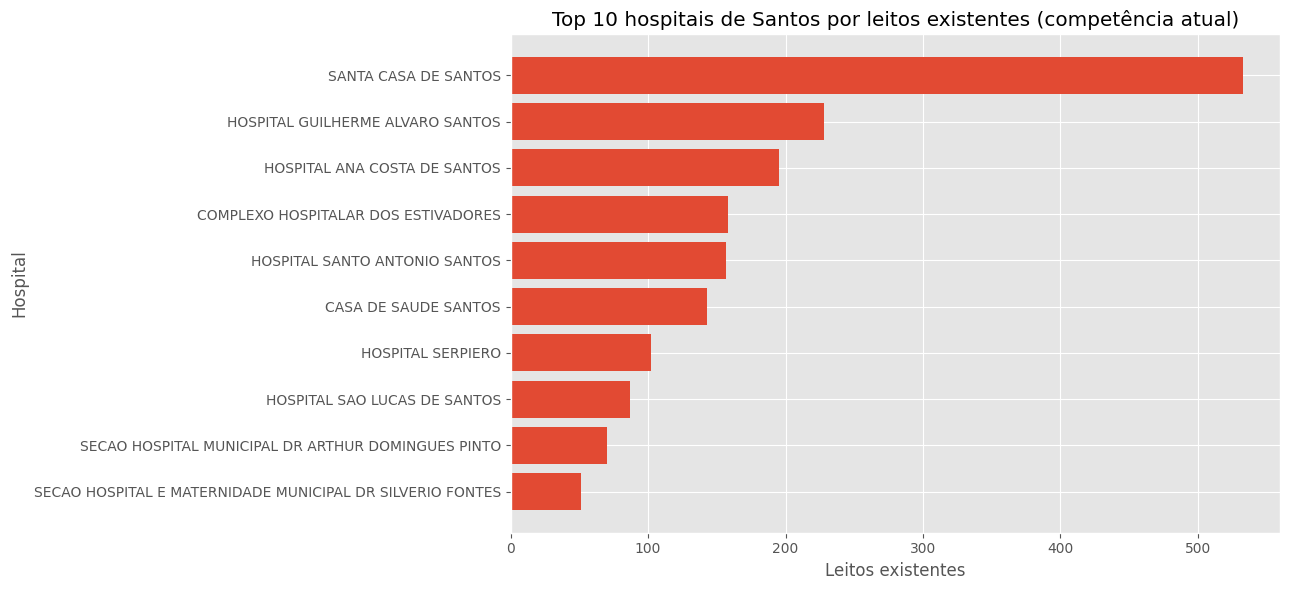

In [ ]:
# Análise por hospital em Santos (competência atual)

hosp_santos = (df_santos_atual
               .groupby(['CNES','NOME_ESTABELECIMENTO','DS_TIPO_UNIDADE','NO_BAIRRO'], as_index=False)
               [['LEITOS_EXISTENTES','LEITOS_SUS','UTI_TOTAL_EXIST','UTI_TOTAL_SUS']]
               .sum())

hosp_santos['Cobertura SUS leitos (%)'] = np.where(
    hosp_santos['LEITOS_EXISTENTES'] > 0,
    100 * hosp_santos['LEITOS_SUS'] / hosp_santos['LEITOS_EXISTENTES'],
    np.nan
)

hosp_santos['UTI sobre leitos (%)'] = np.where(
    hosp_santos['LEITOS_EXISTENTES'] > 0,
    100 * hosp_santos['UTI_TOTAL_EXIST'] / hosp_santos['LEITOS_EXISTENTES'],
    np.nan
)

top_leitos = hosp_santos.sort_values('LEITOS_EXISTENTES', ascending=False)
display(top_leitos.head(12))

plt.figure(figsize=(13, 6))
plot_df = top_leitos.head(10).sort_values('LEITOS_EXISTENTES')
plt.barh(plot_df['NOME_ESTABELECIMENTO'], plot_df['LEITOS_EXISTENTES'])
plt.title('Top 10 hospitais de Santos por leitos existentes (competência atual)')
plt.xlabel('Leitos existentes')
plt.ylabel('Hospital')
plt.tight_layout()
plt.show()

In [ ]:
# Concentração da oferta (Santos)

def hhi(participacoes):
    p = np.array(participacoes)
    return np.sum((p * 100) ** 2)

oferta = top_leitos[['NOME_ESTABELECIMENTO','LEITOS_EXISTENTES']].copy()
oferta['share_leitos'] = oferta['LEITOS_EXISTENTES'] / oferta['LEITOS_EXISTENTES'].sum()
oferta['share_acumulado'] = oferta['share_leitos'].cumsum()

hhi_leitos = hhi(oferta['share_leitos'])

print(f"HHI de leitos em Santos: {hhi_leitos:,.0f}")
print('Leitura prática: quanto maior o HHI, mais concentrada está a oferta em poucos hospitais.')

oferta.head(10)

HHI de leitos em Santos: 1,269
Leitura prática: quanto maior o HHI, mais concentrada está a oferta em poucos hospitais.


,NOME_ESTABELECIMENTO,LEITOS_EXISTENTES,share_leitos,share_acumulado
1,SANTA CASA DE SANTOS,533,0.27,0.27
5,HOSPITAL GUILHERME ALVARO SANTOS,228,0.12,0.39
2,HOSPITAL ANA COSTA DE SANTOS,195,0.10,0.49
15,COMPLEXO HOSPITALAR DOS ESTIVADORES,158,0.08,0.57
6,HOSPITAL SANTO ANTONIO SANTOS,157,0.08,0.66
11,CASA DE SAUDE SANTOS,143,0.07,0.73
13,HOSPITAL SERPIERO,102,0.05,0.78
4,HOSPITAL SAO LUCAS DE SANTOS,87,0.04,0.83
9,SECAO HOSPITAL MUNICIPAL DR ARTHUR DOMINGUES P...,70,0.04,0.86
8,SECAO HOSPITAL E MATERNIDADE MUNICIPAL DR SILV...,51,0.03,0.89


,Subtipo UTI,Existente,SUS,Cobertura SUS (%)
0,Adulto,213,106,49.77
2,Neonatal,59,17,28.81
1,Pediátrico,39,20,51.28
4,Coronariana,30,0,0.00
3,Queimado,0,0,NaN


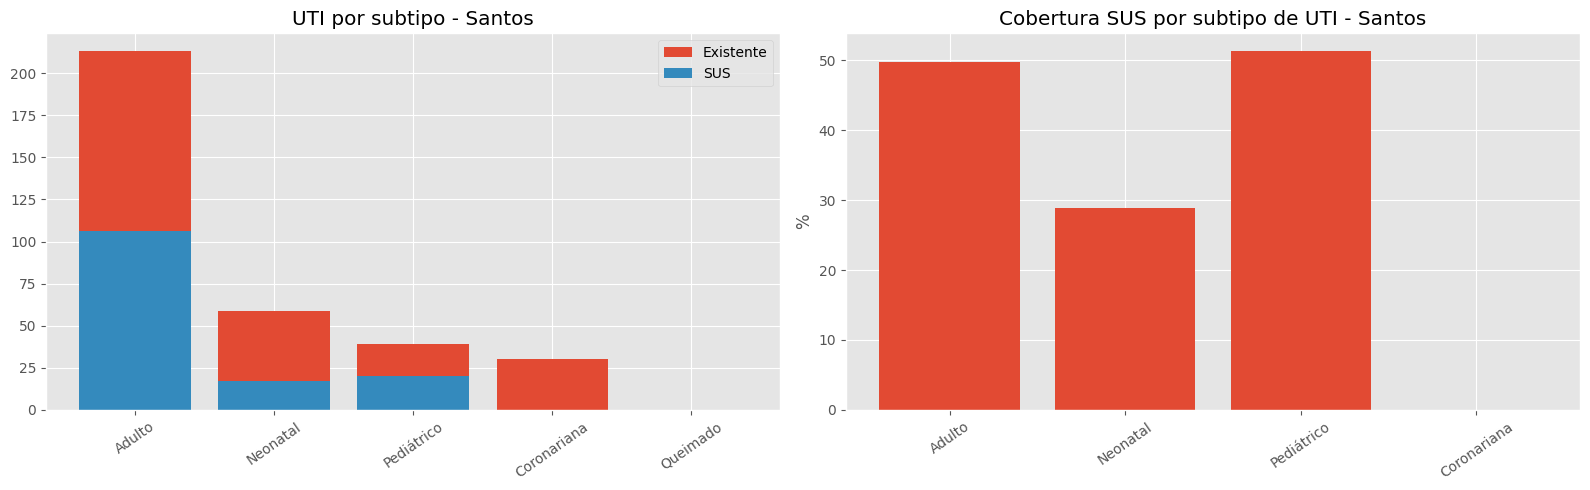

In [ ]:
# Perfil de UTI por subtipo e cobertura SUS (Santos - competência atual)

subtipos = pd.DataFrame({
    'Subtipo UTI': ['Adulto', 'Pediátrico', 'Neonatal', 'Queimado', 'Coronariana'],
    'Existente': [
        df_santos_atual['UTI_ADULTO_EXIST'].sum(),
        df_santos_atual['UTI_PEDIATRICO_EXIST'].sum(),
        df_santos_atual['UTI_NEONATAL_EXIST'].sum(),
        df_santos_atual['UTI_QUEIMADO_EXIST'].sum(),
        df_santos_atual['UTI_CORONARIANA_EXIST'].sum(),
    ],
    'SUS': [
        df_santos_atual['UTI_ADULTO_SUS'].sum(),
        df_santos_atual['UTI_PEDIATRICO_SUS'].sum(),
        df_santos_atual['UTI_NEONATAL_SUS'].sum(),
        df_santos_atual['UTI_QUEIMADO_SUS'].sum(),
        df_santos_atual['UTI_CORONARIANA_SUS'].sum(),
    ]
})

subtipos['Cobertura SUS (%)'] = np.where(subtipos['Existente'] > 0, 100 * subtipos['SUS'] / subtipos['Existente'], np.nan)
subtipos = subtipos.sort_values('Existente', ascending=False)
display(subtipos)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
ax[0].bar(subtipos['Subtipo UTI'], subtipos['Existente'], label='Existente')
ax[0].bar(subtipos['Subtipo UTI'], subtipos['SUS'], label='SUS')
ax[0].set_title('UTI por subtipo - Santos')
ax[0].tick_params(axis='x', rotation=35)
ax[0].legend()

ax[1].bar(subtipos['Subtipo UTI'], subtipos['Cobertura SUS (%)'])
ax[1].set_title('Cobertura SUS por subtipo de UTI - Santos')
ax[1].tick_params(axis='x', rotation=35)
ax[1].set_ylabel('%')

plt.tight_layout()
plt.show()

,NO_BAIRRO,LEITOS_EXISTENTES,LEITOS_SUS,UTI_TOTAL_EXIST,UTI_TOTAL_SUS,Cobertura SUS leitos (%)
4,JABAQUARA,554,277,91,50,50.00
0,BOQUEIRAO,399,223,113,58,55.89
6,VILA BELMIRO,305,47,48,9,15.41
1,CAMPO GRANDE,195,0,43,0,0.00
2,ENCRUZILHADA,185,151,21,14,81.62
7,VILA MATHIAS,143,0,0,0,0.00
5,JARDIM CASTELO,121,116,17,12,95.87
3,GONZAGA,37,0,8,0,0.00


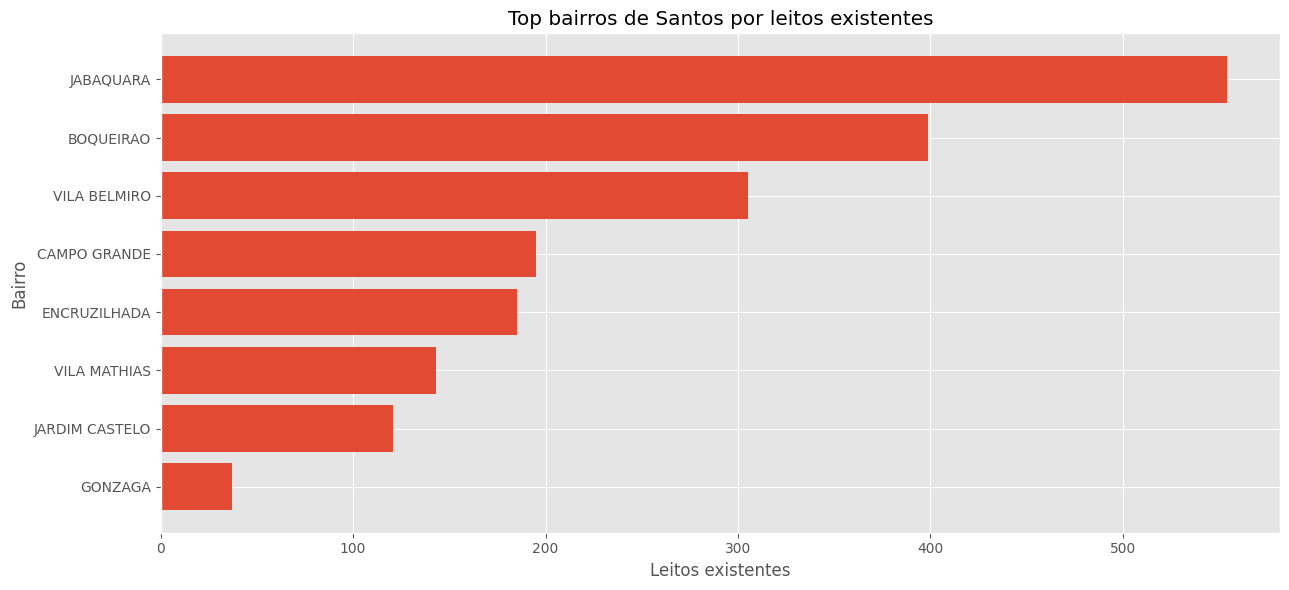

In [ ]:
# Distribuição territorial por bairro (Santos - competência atual)

bairro = (df_santos_atual
          .groupby('NO_BAIRRO', as_index=False)[['LEITOS_EXISTENTES','LEITOS_SUS','UTI_TOTAL_EXIST','UTI_TOTAL_SUS']]
          .sum()
          .sort_values('LEITOS_EXISTENTES', ascending=False))

bairro['Cobertura SUS leitos (%)'] = np.where(
    bairro['LEITOS_EXISTENTES'] > 0,
    100 * bairro['LEITOS_SUS'] / bairro['LEITOS_EXISTENTES'],
    np.nan
)

display(bairro)

plt.figure(figsize=(13, 6))
plot_b = bairro.head(10).sort_values('LEITOS_EXISTENTES')
plt.barh(plot_b['NO_BAIRRO'], plot_b['LEITOS_EXISTENTES'])
plt.title('Top bairros de Santos por leitos existentes')
plt.xlabel('Leitos existentes')
plt.ylabel('Bairro')
plt.tight_layout()
plt.show()

In [ ]:
# Pontos críticos para gestão pública

# 1) Hospitais com leitos mas sem oferta SUS
sem_sus = hosp_santos[(hosp_santos['LEITOS_EXISTENTES'] > 0) & (hosp_santos['LEITOS_SUS'] == 0)]    .sort_values('LEITOS_EXISTENTES', ascending=False)

# 2) Possíveis fragilidades cadastrais (contato)
contato = (df_santos_atual[['CNES','NOME_ESTABELECIMENTO','NU_TELEFONE','NO_EMAIL']]
           .drop_duplicates())
contato['telefone_vazio'] = contato['NU_TELEFONE'].isna() | (contato['NU_TELEFONE'].astype(str).str.strip() == '')
contato['email_vazio'] = contato['NO_EMAIL'].isna() | (contato['NO_EMAIL'].astype(str).str.strip() == '')

print('Hospitais com leitos e zero leitos SUS:', sem_sus.shape[0])
display(sem_sus[['NOME_ESTABELECIMENTO','LEITOS_EXISTENTES','UTI_TOTAL_EXIST','NO_BAIRRO']])

print('Contatos faltantes (telefone ou e-mail):')
display(contato[['NOME_ESTABELECIMENTO','telefone_vazio','email_vazio']].sort_values(['telefone_vazio','email_vazio'], ascending=False))

Hospitais com leitos e zero leitos SUS: 10


,NOME_ESTABELECIMENTO,LEITOS_EXISTENTES,UTI_TOTAL_EXIST,NO_BAIRRO
2,HOSPITAL ANA COSTA DE SANTOS,195,43,CAMPO GRANDE
11,CASA DE SAUDE SANTOS,143,55,BOQUEIRAO
13,HOSPITAL SERPIERO,102,0,VILA MATHIAS
4,HOSPITAL SAO LUCAS DE SANTOS,87,20,VILA BELMIRO
14,HOSPITAL SANTO EXPEDITO,49,10,VILA BELMIRO
0,CENTRO MEDICO,41,0,VILA MATHIAS
12,INFANTIL SANTOS COOPERATIVA MEDICO HOSPITALAR,37,8,GONZAGA
7,HOSPITAL FREI GALVAO,28,0,BOQUEIRAO
10,MED CENTER,27,0,ENCRUZILHADA
16,ANGIOCORPORE,12,0,VILA BELMIRO


Contatos faltantes (telefone ou e-mail):


,NOME_ESTABELECIMENTO,telefone_vazio,email_vazio
20091,HOSPITAL SERPIERO,True,True
14761,CENTRO MEDICO,False,True
18627,SECAO HOSPITAL E MATERNIDADE MUNICIPAL DR SILV...,False,True
18628,SECAO HOSPITAL MUNICIPAL DR ARTHUR DOMINGUES P...,False,True
18634,MED CENTER,False,True
20862,COMPLEXO HOSPITALAR DOS ESTIVADORES,False,True
15005,SANTA CASA DE SANTOS,False,False
15006,HOSPITAL ANA COSTA DE SANTOS,False,False
15024,SECAO PRONTO SOCORRO CENTRAL SEPROS C,False,False
15130,HOSPITAL SAO LUCAS DE SANTOS,False,False


In [ ]:
# Simulação de meta: quanto faltaria para Santos atingir referências de cobertura SUS?

santos_total = df_santos_atual['LEITOS_EXISTENTES'].sum()
santos_sus = df_santos_atual['LEITOS_SUS'].sum()

sp_pct_sus = (df_atual[df_atual['UF_NORM']=='SP']['LEITOS_SUS'].sum() /
              df_atual[df_atual['UF_NORM']=='SP']['LEITOS_EXISTENTES'].sum())
br_pct_sus = (df_atual['LEITOS_SUS'].sum() / df_atual['LEITOS_EXISTENTES'].sum())

meta_sp = int(round(santos_total * sp_pct_sus))
meta_br = int(round(santos_total * br_pct_sus))

sim = pd.DataFrame([
    {'Cenário': 'Atual Santos', 'Leitos SUS alvo': santos_sus, 'Leitos SUS adicionais necessários': 0},
    {'Cenário': 'Se igualar SP', 'Leitos SUS alvo': meta_sp, 'Leitos SUS adicionais necessários': max(meta_sp - santos_sus, 0)},
    {'Cenário': 'Se igualar Brasil', 'Leitos SUS alvo': meta_br, 'Leitos SUS adicionais necessários': max(meta_br - santos_sus, 0)},
])

sim

,Cenário,Leitos SUS alvo,Leitos SUS adicionais necessários
0,Atual Santos,814,0
1,Se igualar SP,1095,281
2,Se igualar Brasil,1314,500


## Painéis Críticos Adicionais

Os gráficos abaixo foram desenhados para destacar **problemas práticos de gestão**, não apenas descrever números.

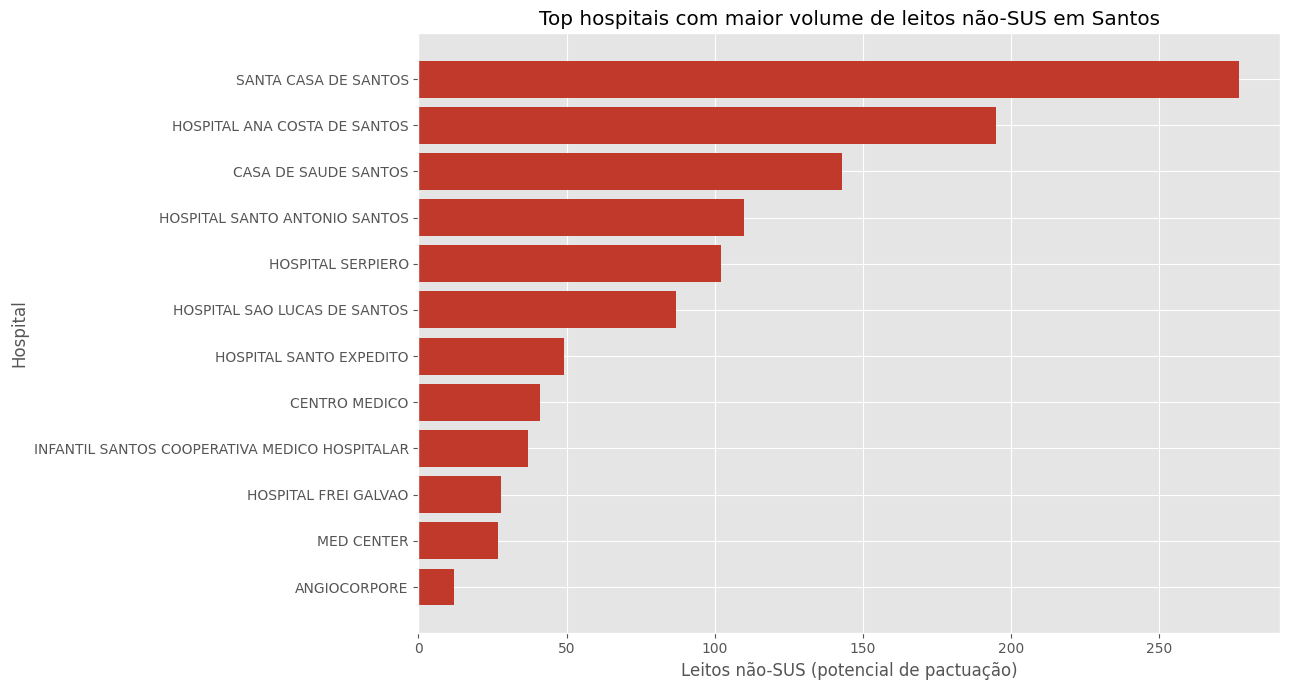

Leitura crítica: grande parte do déficit SUS está concentrada em poucos hospitais de alta capacidade.


,NOME_ESTABELECIMENTO,LEITOS_EXISTENTES,LEITOS_SUS,LEITOS_NAO_SUS,Cobertura SUS leitos (%)
1,SANTA CASA DE SANTOS,533,256,277,48.03
2,HOSPITAL ANA COSTA DE SANTOS,195,0,195,0.00
11,CASA DE SAUDE SANTOS,143,0,143,0.00
6,HOSPITAL SANTO ANTONIO SANTOS,157,47,110,29.94
13,HOSPITAL SERPIERO,102,0,102,0.00
4,HOSPITAL SAO LUCAS DE SANTOS,87,0,87,0.00
14,HOSPITAL SANTO EXPEDITO,49,0,49,0.00
0,CENTRO MEDICO,41,0,41,0.00
12,INFANTIL SANTOS COOPERATIVA MEDICO HOSPITALAR,37,0,37,0.00
7,HOSPITAL FREI GALVAO,28,0,28,0.00


In [ ]:
# Painel 1: Gap de leitos não-SUS por hospital (onde está o principal déficit de acesso público)

painel_hosp = hosp_santos.copy()
painel_hosp['LEITOS_NAO_SUS'] = painel_hosp['LEITOS_EXISTENTES'] - painel_hosp['LEITOS_SUS']
painel_hosp['Cobertura SUS leitos (%)'] = np.where(
    painel_hosp['LEITOS_EXISTENTES'] > 0,
    100 * painel_hosp['LEITOS_SUS'] / painel_hosp['LEITOS_EXISTENTES'],
    np.nan
)

plot_gap = painel_hosp.sort_values('LEITOS_NAO_SUS', ascending=False).head(12).copy()
plot_gap = plot_gap.sort_values('LEITOS_NAO_SUS', ascending=True)

plt.figure(figsize=(13, 7))
plt.barh(plot_gap['NOME_ESTABELECIMENTO'], plot_gap['LEITOS_NAO_SUS'], color='#C0392B')
plt.title('Top hospitais com maior volume de leitos não-SUS em Santos')
plt.xlabel('Leitos não-SUS (potencial de pactuação)')
plt.ylabel('Hospital')
plt.tight_layout()
plt.show()

criticos_gap = painel_hosp[painel_hosp['LEITOS_NAO_SUS'] > 0].sort_values('LEITOS_NAO_SUS', ascending=False)
print('Leitura crítica: grande parte do déficit SUS está concentrada em poucos hospitais de alta capacidade.')
display(criticos_gap[['NOME_ESTABELECIMENTO','LEITOS_EXISTENTES','LEITOS_SUS','LEITOS_NAO_SUS','Cobertura SUS leitos (%)']].head(10))

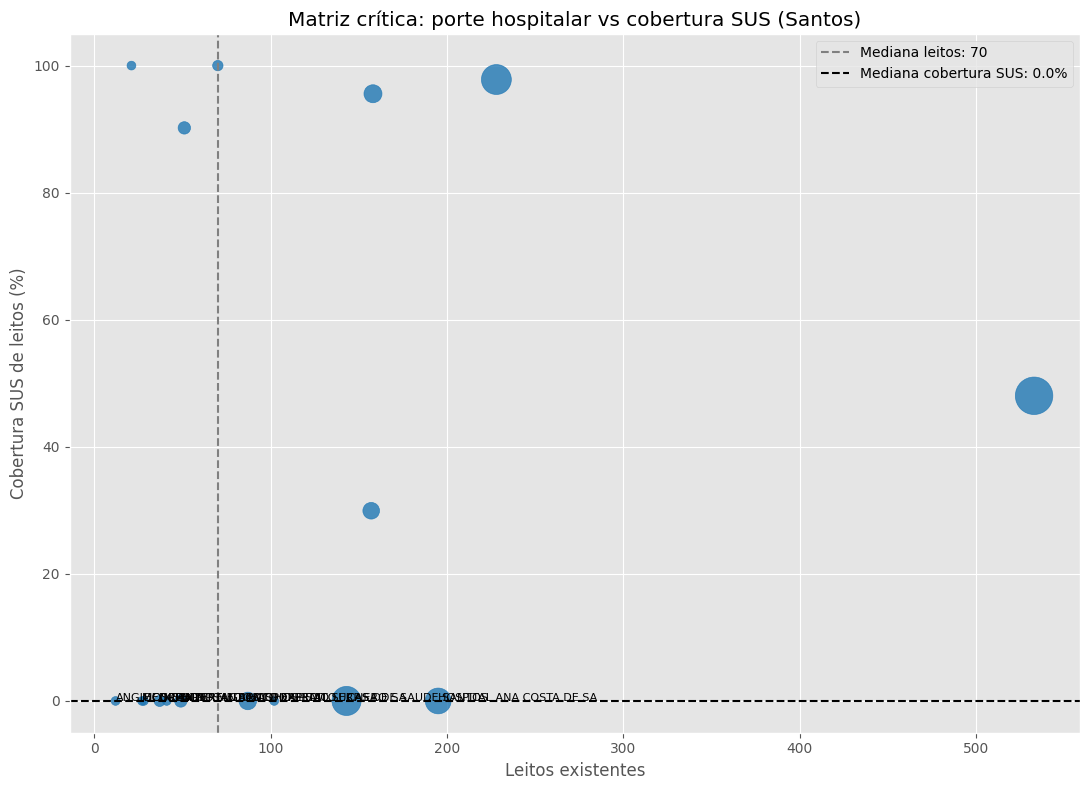

Leitura crítica: hospitais grandes com baixa cobertura SUS são os pontos prioritários de intervenção regulatória.


,NOME_ESTABELECIMENTO,LEITOS_EXISTENTES,LEITOS_SUS,Cobertura SUS leitos (%),UTI_TOTAL_EXIST
2,HOSPITAL ANA COSTA DE SANTOS,195,0,0.00,43
11,CASA DE SAUDE SANTOS,143,0,0.00,55
13,HOSPITAL SERPIERO,102,0,0.00,0
4,HOSPITAL SAO LUCAS DE SANTOS,87,0,0.00,20


In [ ]:
# Painel 2: Matriz de risco (porte hospitalar x cobertura SUS)

matriz = painel_hosp.copy()
matriz['Cobertura SUS leitos (%)'] = np.where(
    matriz['LEITOS_EXISTENTES'] > 0,
    100 * matriz['LEITOS_SUS'] / matriz['LEITOS_EXISTENTES'],
    np.nan
)

med_leitos = matriz['LEITOS_EXISTENTES'].median()
med_cob = matriz['Cobertura SUS leitos (%)'].median()

plt.figure(figsize=(11, 8))
plt.scatter(
    matriz['LEITOS_EXISTENTES'],
    matriz['Cobertura SUS leitos (%)'],
    s=np.maximum(matriz['UTI_TOTAL_EXIST'], 5) * 8,
    alpha=0.8,
    color='#1f77b4'
)

for _, r in matriz.iterrows():
    if (r['LEITOS_EXISTENTES'] >= med_leitos and r['Cobertura SUS leitos (%)'] <= med_cob) or r['Cobertura SUS leitos (%)'] == 0:
        plt.annotate(r['NOME_ESTABELECIMENTO'][:24], (r['LEITOS_EXISTENTES'], r['Cobertura SUS leitos (%)']), fontsize=8)

plt.axvline(med_leitos, linestyle='--', color='gray', label=f'Mediana leitos: {med_leitos:.0f}')
plt.axhline(med_cob, linestyle='--', color='black', label=f'Mediana cobertura SUS: {med_cob:.1f}%')
plt.title('Matriz crítica: porte hospitalar vs cobertura SUS (Santos)')
plt.xlabel('Leitos existentes')
plt.ylabel('Cobertura SUS de leitos (%)')
plt.legend()
plt.tight_layout()
plt.show()

risco_alto = matriz[(matriz['LEITOS_EXISTENTES'] >= med_leitos) & (matriz['Cobertura SUS leitos (%)'] <= med_cob)]    .sort_values(['LEITOS_EXISTENTES','Cobertura SUS leitos (%)'], ascending=[False, True])

print('Leitura crítica: hospitais grandes com baixa cobertura SUS são os pontos prioritários de intervenção regulatória.')
display(risco_alto[['NOME_ESTABELECIMENTO','LEITOS_EXISTENTES','LEITOS_SUS','Cobertura SUS leitos (%)','UTI_TOTAL_EXIST']])

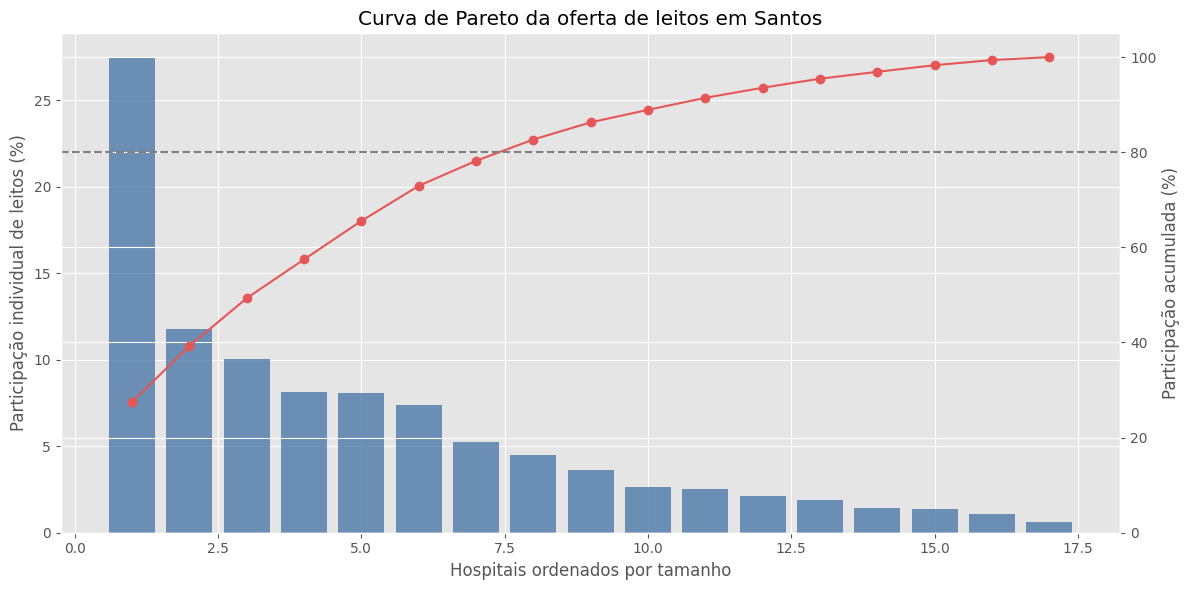

Leitura crítica: aproximadamente 8 hospitais concentram ~80% dos leitos de Santos.
Risco associado: qualquer ruptura operacional nesses hospitais tem alto impacto sistêmico.


In [ ]:
# Painel 3: Curva de Pareto da oferta (dependência de poucos hospitais)

pareto = painel_hosp[['NOME_ESTABELECIMENTO','LEITOS_EXISTENTES']].sort_values('LEITOS_EXISTENTES', ascending=False).copy()
pareto['share_%'] = 100 * pareto['LEITOS_EXISTENTES'] / pareto['LEITOS_EXISTENTES'].sum()
pareto['acumulado_%'] = pareto['share_%'].cumsum()
pareto['ordem'] = range(1, len(pareto)+1)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(pareto['ordem'], pareto['share_%'], color='#4C78A8', alpha=0.8)
ax1.set_xlabel('Hospitais ordenados por tamanho')
ax1.set_ylabel('Participação individual de leitos (%)')

ax2 = ax1.twinx()
ax2.plot(pareto['ordem'], pareto['acumulado_%'], color='#E45756', marker='o')
ax2.axhline(80, linestyle='--', color='gray')
ax2.set_ylabel('Participação acumulada (%)')
ax2.set_ylim(0, 105)

plt.title('Curva de Pareto da oferta de leitos em Santos')
plt.tight_layout()
plt.show()

n80 = int((pareto['acumulado_%'] < 80).sum() + 1)
print(f'Leitura crítica: aproximadamente {n80} hospitais concentram ~80% dos leitos de Santos.')
print('Risco associado: qualquer ruptura operacional nesses hospitais tem alto impacto sistêmico.')

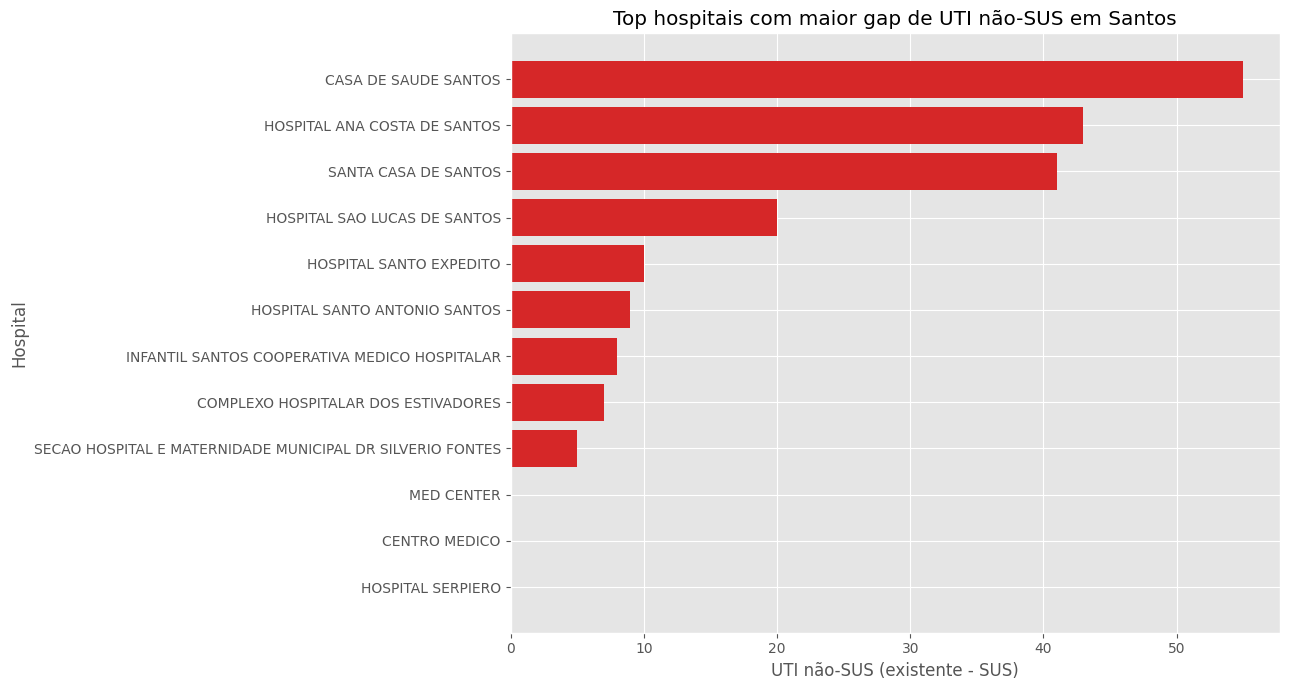

Leitura crítica: existem hospitais com UTI instalada e zero UTI SUS, ponto crítico para acesso de alta complexidade.


,NOME_ESTABELECIMENTO,UTI_TOTAL_EXIST,UTI_TOTAL_SUS,UTI_NAO_SUS
11,CASA DE SAUDE SANTOS,55,0,55
2,HOSPITAL ANA COSTA DE SANTOS,43,0,43
4,HOSPITAL SAO LUCAS DE SANTOS,20,0,20
14,HOSPITAL SANTO EXPEDITO,10,0,10
12,INFANTIL SANTOS COOPERATIVA MEDICO HOSPITALAR,8,0,8


In [ ]:
# Painel 4: Gap de UTI SUS (capacidade instalada sem acesso público proporcional)

uti = painel_hosp[['NOME_ESTABELECIMENTO','UTI_TOTAL_EXIST','UTI_TOTAL_SUS','LEITOS_EXISTENTES','LEITOS_SUS']].copy()
uti['UTI_NAO_SUS'] = uti['UTI_TOTAL_EXIST'] - uti['UTI_TOTAL_SUS']
uti = uti.sort_values('UTI_NAO_SUS', ascending=False)

plot_uti = uti.head(12).sort_values('UTI_NAO_SUS', ascending=True)

plt.figure(figsize=(13, 7))
plt.barh(plot_uti['NOME_ESTABELECIMENTO'], plot_uti['UTI_NAO_SUS'], color='#D62728')
plt.title('Top hospitais com maior gap de UTI não-SUS em Santos')
plt.xlabel('UTI não-SUS (existente - SUS)')
plt.ylabel('Hospital')
plt.tight_layout()
plt.show()

uti_zero_sus = uti[(uti['UTI_TOTAL_EXIST'] > 0) & (uti['UTI_TOTAL_SUS'] == 0)]
print('Leitura crítica: existem hospitais com UTI instalada e zero UTI SUS, ponto crítico para acesso de alta complexidade.')
display(uti_zero_sus[['NOME_ESTABELECIMENTO','UTI_TOTAL_EXIST','UTI_TOTAL_SUS','UTI_NAO_SUS']])

,CNES,NOME_ESTABELECIMENTO,Variacao LEITOS_SUS,Variacao UTI_SUS
6,2080354,HOSPITAL SANTO ANTONIO SANTOS,10,0
0,684910,CENTRO MEDICO,0,0
9,2698471,SECAO HOSPITAL MUNICIPAL DR ARTHUR DOMINGUES P...,0,0
15,6998704,COMPLEXO HOSPITALAR DOS ESTIVADORES,0,0
14,5654688,HOSPITAL SANTO EXPEDITO,0,0
13,4205898,HOSPITAL SERPIERO,0,0
12,3221792,INFANTIL SANTOS COOPERATIVA MEDICO HOSPITALAR,0,0
11,3008398,CASA DE SAUDE SANTOS,0,0
10,2702622,MED CENTER,0,0
8,2698463,SECAO HOSPITAL E MATERNIDADE MUNICIPAL DR SILV...,0,0


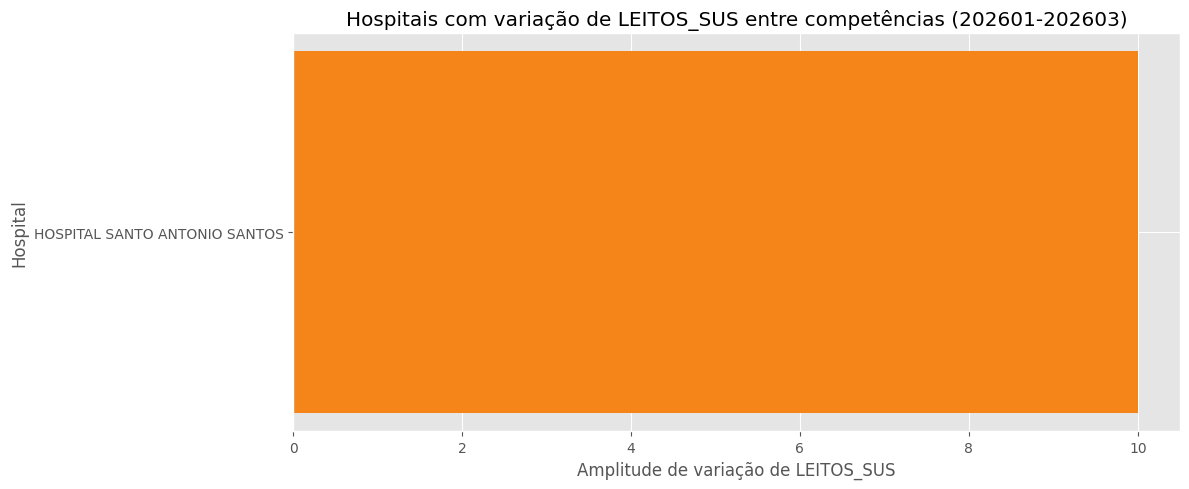

Leitura crítica: variações podem refletir ajuste real de oferta, contratualização ou atraso de atualização cadastral.
Ação recomendada: auditar os maiores deltas para separar mudança operacional de inconsistência de registro.


In [ ]:
# Painel 5: Variação entre competências (sinal de instabilidade/atualização operacional)

# Mudanças mensais em leitos SUS por hospital
serie_hosp = (df_santos
    .groupby(['COMP','CNES','NOME_ESTABELECIMENTO'], as_index=False)[['LEITOS_SUS','UTI_TOTAL_SUS']]
    .sum()
    .sort_values(['CNES','COMP']))

var_hosp = []
for cnes, g in serie_hosp.groupby('CNES'):
    g = g.sort_values('COMP').copy()
    d_leitos = g['LEITOS_SUS'].max() - g['LEITOS_SUS'].min()
    d_uti = g['UTI_TOTAL_SUS'].max() - g['UTI_TOTAL_SUS'].min()
    var_hosp.append({
        'CNES': cnes,
        'NOME_ESTABELECIMENTO': g['NOME_ESTABELECIMENTO'].iloc[0],
        'Variacao LEITOS_SUS': d_leitos,
        'Variacao UTI_SUS': d_uti
    })

var_hosp = pd.DataFrame(var_hosp).sort_values('Variacao LEITOS_SUS', ascending=False)
display(var_hosp.head(10))

mudancas = var_hosp[var_hosp['Variacao LEITOS_SUS'] > 0]
if not mudancas.empty:
    plt.figure(figsize=(12, 5))
    plot_m = mudancas.head(10).sort_values('Variacao LEITOS_SUS')
    plt.barh(plot_m['NOME_ESTABELECIMENTO'], plot_m['Variacao LEITOS_SUS'], color='#F58518')
    plt.title('Hospitais com variação de LEITOS_SUS entre competências (202601-202603)')
    plt.xlabel('Amplitude de variação de LEITOS_SUS')
    plt.ylabel('Hospital')
    plt.tight_layout()
    plt.show()

print('Leitura crítica: variações podem refletir ajuste real de oferta, contratualização ou atraso de atualização cadastral.')
print('Ação recomendada: auditar os maiores deltas para separar mudança operacional de inconsistência de registro.')

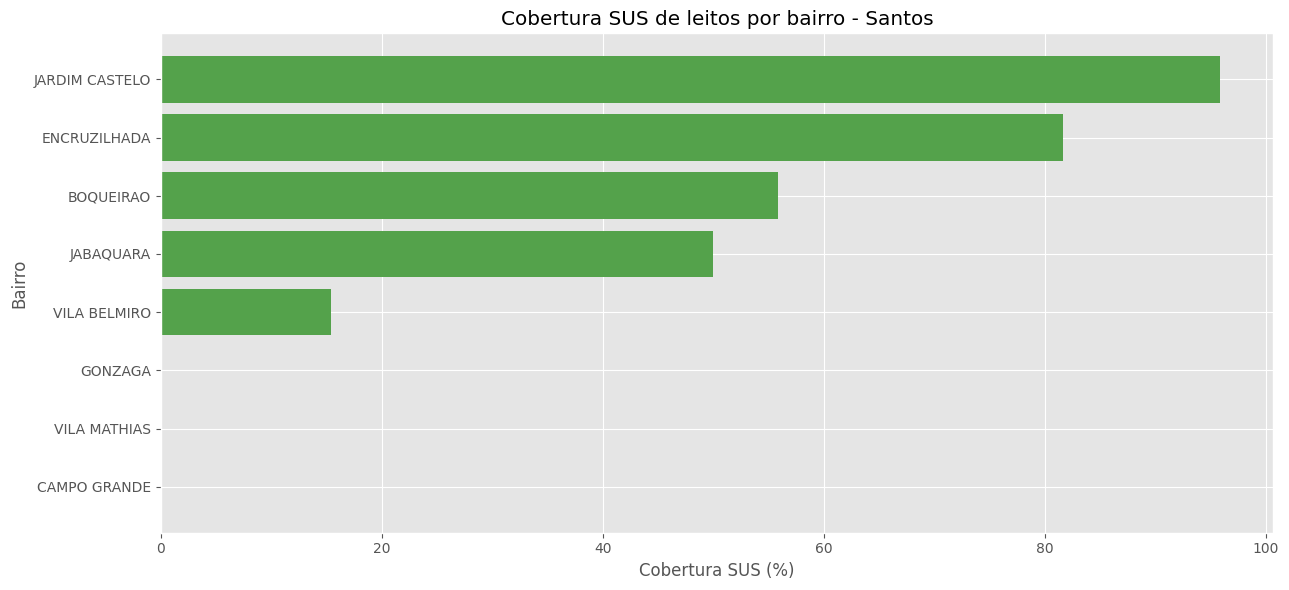

Leitura crítica: bairros com baixa cobertura SUS e alta oferta total podem esconder barreiras de acesso público.


,NO_BAIRRO,LEITOS_EXISTENTES,LEITOS_SUS,Cobertura SUS leitos (%)
1,CAMPO GRANDE,195,0,0.00
7,VILA MATHIAS,143,0,0.00
3,GONZAGA,37,0,0.00
6,VILA BELMIRO,305,47,15.41
4,JABAQUARA,554,277,50.00


In [ ]:
# Painel 6: Cobertura SUS por bairro (desigualdade territorial)

bairro2 = bairro.copy()

plt.figure(figsize=(13, 6))
plot_b2 = bairro2.sort_values('Cobertura SUS leitos (%)', ascending=True)
plt.barh(plot_b2['NO_BAIRRO'], plot_b2['Cobertura SUS leitos (%)'], color='#54A24B')
plt.title('Cobertura SUS de leitos por bairro - Santos')
plt.xlabel('Cobertura SUS (%)')
plt.ylabel('Bairro')
plt.tight_layout()
plt.show()

baixo_sus_bairro = bairro2.sort_values('Cobertura SUS leitos (%)').head(5)
print('Leitura crítica: bairros com baixa cobertura SUS e alta oferta total podem esconder barreiras de acesso público.')
display(baixo_sus_bairro[['NO_BAIRRO','LEITOS_EXISTENTES','LEITOS_SUS','Cobertura SUS leitos (%)']])

## Gráficos Visuais para Apresentação

Painel visual com foco em storytelling executivo: cobertura SUS, comparação de desempenho e risco de acesso.

In [ ]:
# Tema visual para apresentação
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

CORES = {
    'sus': '#2E8B57',
    'nao_sus': '#D64B4B',
    'neutro': '#4C78A8',
    'destaque': '#F39C12',
    'escuro': '#2C3E50',
    'claro': '#EAECEF'
}

print('Tema visual aplicado.')

Tema visual aplicado.


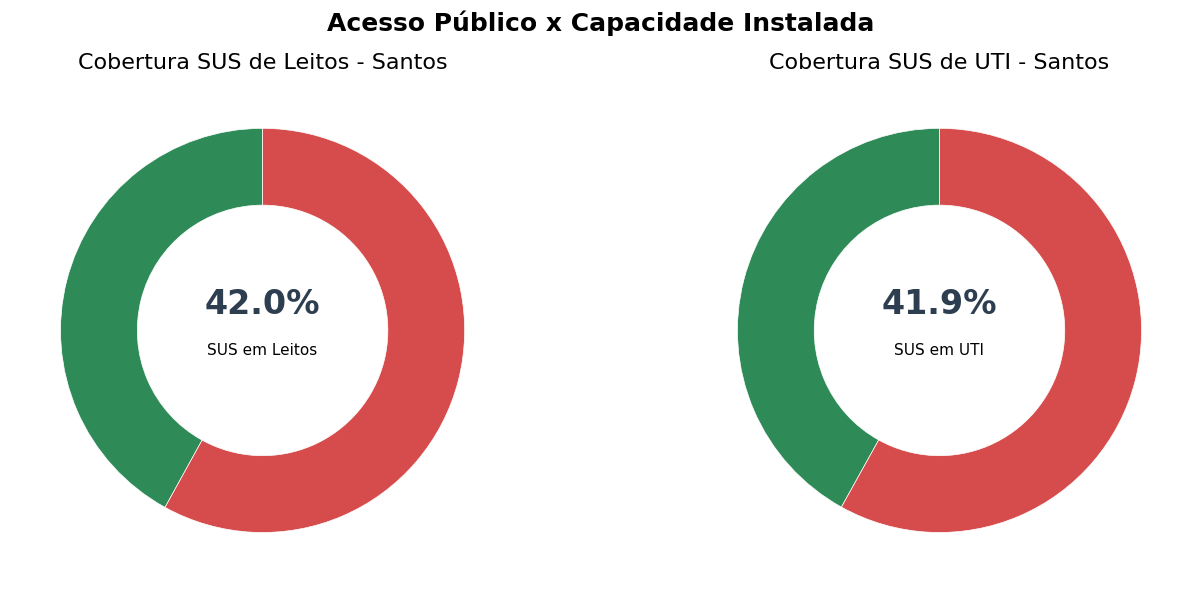

Leitos SUS: 814 | Não SUS: 1125
UTI SUS: 143 | Não SUS: 198


In [ ]:
# Painel Visual 1: Donuts de cobertura SUS (leitos e UTI)
leitos_total = int(df_santos_atual['LEITOS_EXISTENTES'].sum())
leitos_sus = int(df_santos_atual['LEITOS_SUS'].sum())
leitos_nao_sus = leitos_total - leitos_sus

uti_total = int(df_santos_atual['UTI_TOTAL_EXIST'].sum())
uti_sus = int(df_santos_atual['UTI_TOTAL_SUS'].sum())
uti_nao_sus = uti_total - uti_sus

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].pie([leitos_sus, leitos_nao_sus], startangle=90,
          colors=[CORES['sus'], CORES['nao_sus']],
          wedgeprops=dict(width=0.38, edgecolor='white'))
ax[0].text(0, 0.08, f"{(100*leitos_sus/leitos_total):.1f}%", ha='center', fontsize=24, fontweight='bold', color=CORES['escuro'])
ax[0].text(0, -0.12, 'SUS em Leitos', ha='center', fontsize=11)
ax[0].set_title('Cobertura SUS de Leitos - Santos')

ax[1].pie([uti_sus, uti_nao_sus], startangle=90,
          colors=[CORES['sus'], CORES['nao_sus']],
          wedgeprops=dict(width=0.38, edgecolor='white'))
ax[1].text(0, 0.08, f"{(100*uti_sus/uti_total):.1f}%", ha='center', fontsize=24, fontweight='bold', color=CORES['escuro'])
ax[1].text(0, -0.12, 'SUS em UTI', ha='center', fontsize=11)
ax[1].set_title('Cobertura SUS de UTI - Santos')

plt.suptitle('Acesso Público x Capacidade Instalada', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Leitos SUS: {leitos_sus} | Não SUS: {leitos_nao_sus}")
print(f"UTI SUS: {uti_sus} | Não SUS: {uti_nao_sus}")

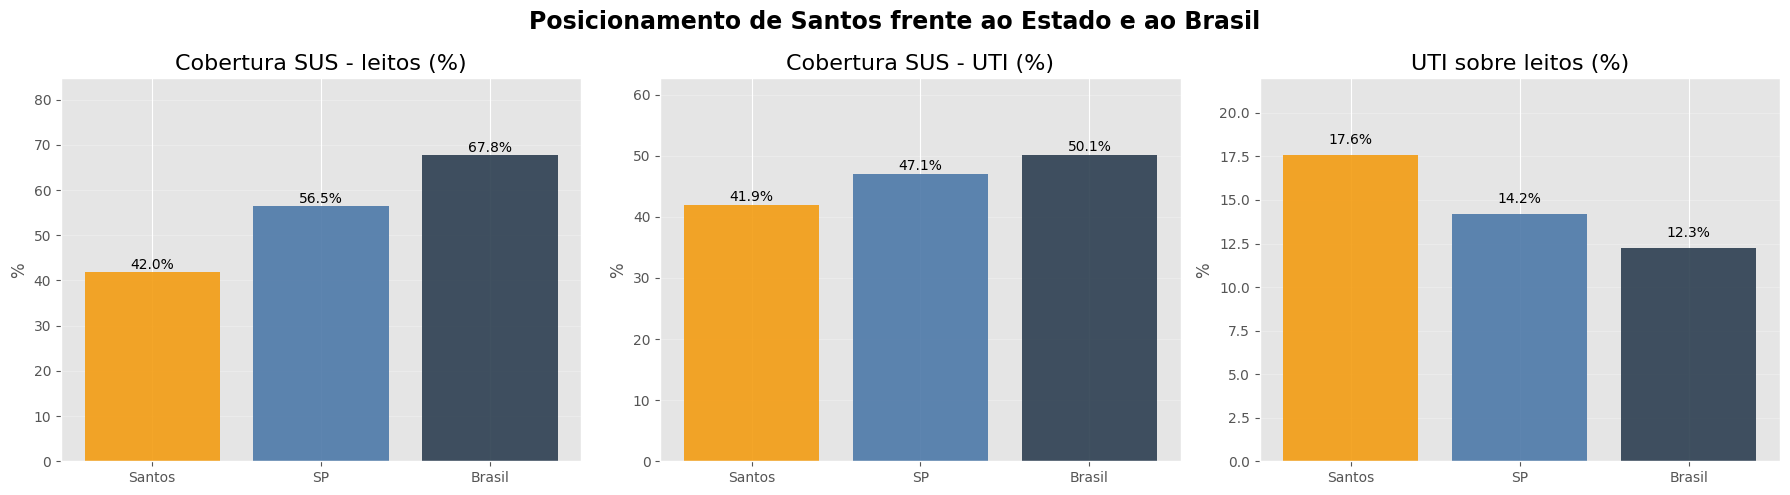

Leitura visual: Santos aparece abaixo de SP e Brasil em cobertura SUS de leitos e UTI.


In [ ]:
# Painel Visual 2: Benchmark com barras de referencia (Santos x SP x Brasil)
comp = benchmark[['Cobertura SUS - leitos (%)','Cobertura SUS - UTI (%)','UTI sobre leitos (%)']].copy()
comp.index = ['Santos', 'SP', 'Brasil']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metricas = list(comp.columns)

for i, m in enumerate(metricas):
    vals = comp[m].values
    cores = [CORES['destaque'], CORES['neutro'], CORES['escuro']]
    bars = axes[i].bar(comp.index, vals, color=cores, alpha=0.9)
    axes[i].set_title(m)
    axes[i].set_ylabel('%')
    axes[i].set_ylim(0, max(vals) * 1.25)
    for b, v in zip(bars, vals):
        axes[i].text(b.get_x()+b.get_width()/2, b.get_height()+0.6, f"{v:.1f}%", ha='center', fontsize=10)
    axes[i].grid(axis='y', alpha=0.25)

plt.suptitle('Posicionamento de Santos frente ao Estado e ao Brasil', fontsize=17, fontweight='bold')
plt.tight_layout()
plt.show()

print('Leitura visual: Santos aparece abaixo de SP e Brasil em cobertura SUS de leitos e UTI.')

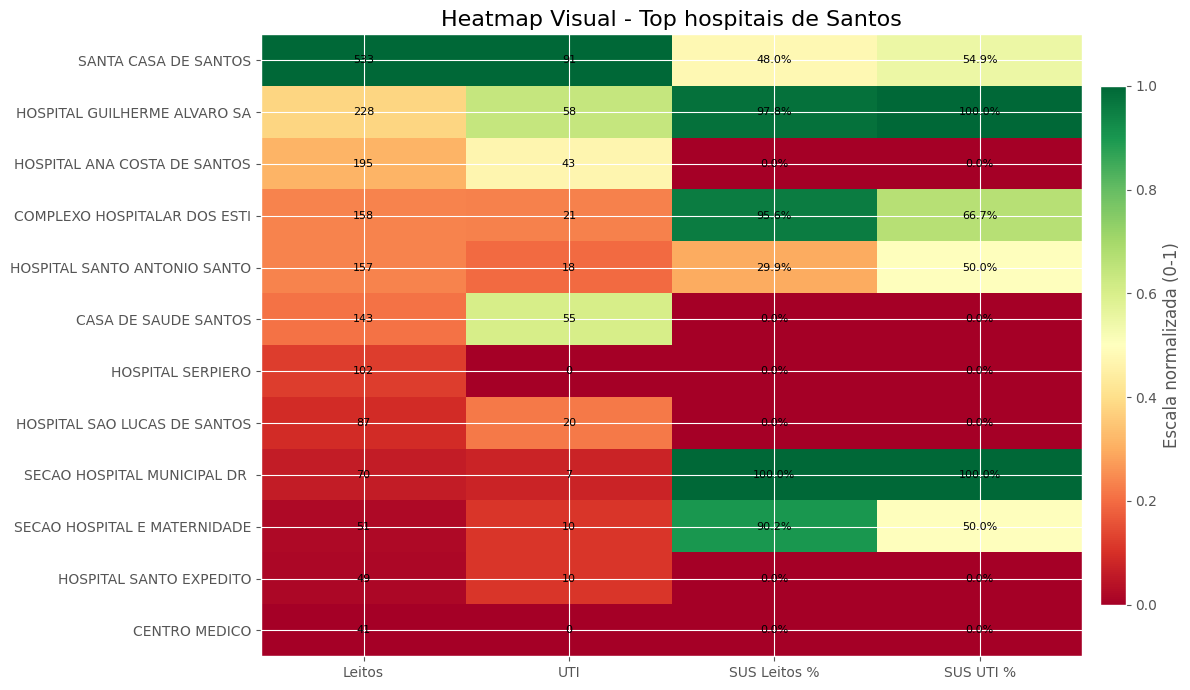

Leitura visual: grandes blocos com baixa cobertura SUS devem ser prioridade de pactuacao.


In [ ]:
# Painel Visual 3: Heatmap de risco por hospital (tamanho, SUS e UTI)
heat = hosp_santos[['NOME_ESTABELECIMENTO','LEITOS_EXISTENTES','LEITOS_SUS','UTI_TOTAL_EXIST','UTI_TOTAL_SUS']].copy()
heat['Cobertura_SUS_Leitos_%'] = np.where(heat['LEITOS_EXISTENTES']>0, 100*heat['LEITOS_SUS']/heat['LEITOS_EXISTENTES'], 0)
heat['Cobertura_SUS_UTI_%'] = np.where(heat['UTI_TOTAL_EXIST']>0, 100*heat['UTI_TOTAL_SUS']/heat['UTI_TOTAL_EXIST'], 0)

heat = heat.sort_values('LEITOS_EXISTENTES', ascending=False).head(12).copy()
mat = heat[['LEITOS_EXISTENTES','UTI_TOTAL_EXIST','Cobertura_SUS_Leitos_%','Cobertura_SUS_UTI_%']]

# normalizacao para facilitar leitura do mapa
mat_norm = (mat - mat.min()) / (mat.max() - mat.min() + 1e-9)

fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(mat_norm.values, aspect='auto', cmap='RdYlGn')
ax.set_xticks(range(mat_norm.shape[1]))
ax.set_xticklabels(['Leitos', 'UTI', 'SUS Leitos %', 'SUS UTI %'])
ax.set_yticks(range(mat_norm.shape[0]))
ax.set_yticklabels([n[:28] for n in heat['NOME_ESTABELECIMENTO']])
ax.set_title('Heatmap Visual - Top hospitais de Santos')

for i in range(mat_norm.shape[0]):
    for j in range(mat_norm.shape[1]):
        val_real = mat.iloc[i, j]
        txt = f"{val_real:.0f}" if j < 2 else f"{val_real:.1f}%"
        ax.text(j, i, txt, ha='center', va='center', fontsize=8, color='black')

plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label='Escala normalizada (0-1)')
plt.tight_layout()
plt.show()

print('Leitura visual: grandes blocos com baixa cobertura SUS devem ser prioridade de pactuacao.')

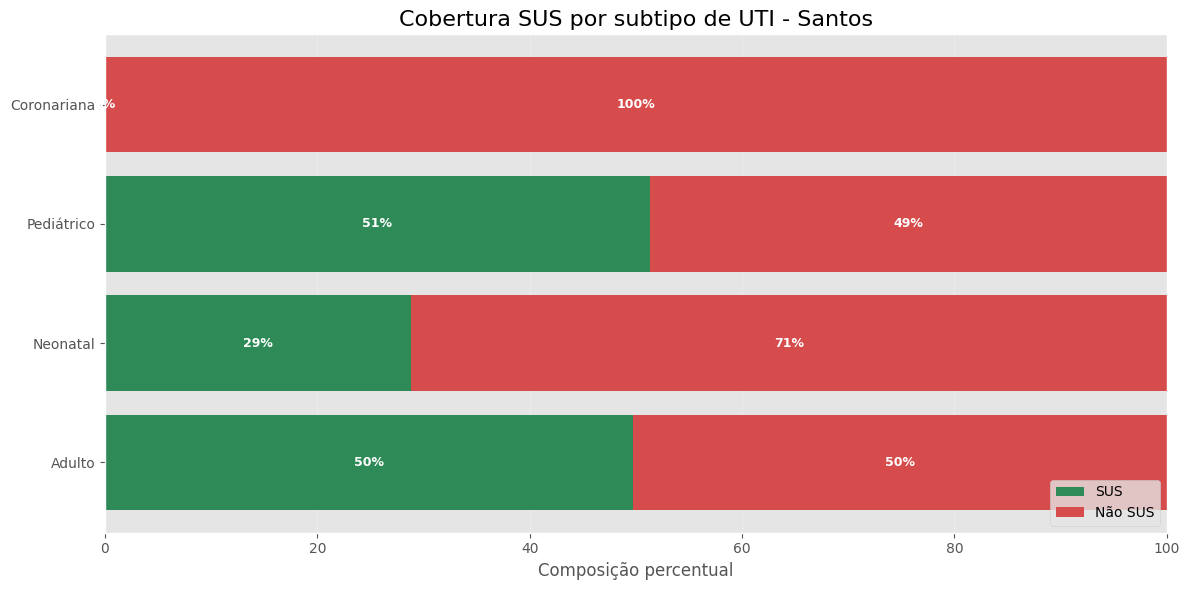

Leitura visual: subtipos com fatia SUS pequena indicam gargalo de alta complexidade no acesso público.


In [ ]:
# Painel Visual 4: UTI por subtipo em barra 100% empilhada (SUS x Não SUS)
sub = subtipos.copy()
sub['Nao_SUS'] = sub['Existente'] - sub['SUS']
sub = sub[sub['Existente'] > 0].copy()
sub['SUS_%'] = 100 * sub['SUS'] / sub['Existente']
sub['Nao_SUS_%'] = 100 - sub['SUS_%']

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(sub['Subtipo UTI'], sub['SUS_%'], color=CORES['sus'], label='SUS')
ax.barh(sub['Subtipo UTI'], sub['Nao_SUS_%'], left=sub['SUS_%'], color=CORES['nao_sus'], label='Não SUS')

for i, (_, r) in enumerate(sub.iterrows()):
    ax.text(r['SUS_%']/2, i, f"{r['SUS_%']:.0f}%", ha='center', va='center', color='white', fontsize=9, fontweight='bold')
    if r['Nao_SUS_%'] > 8:
        ax.text(r['SUS_%'] + r['Nao_SUS_%']/2, i, f"{r['Nao_SUS_%']:.0f}%", ha='center', va='center', color='white', fontsize=9, fontweight='bold')

ax.set_xlim(0, 100)
ax.set_xlabel('Composição percentual')
ax.set_title('Cobertura SUS por subtipo de UTI - Santos')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

print('Leitura visual: subtipos com fatia SUS pequena indicam gargalo de alta complexidade no acesso público.')

## Leitura Crítica e Recomendações (Santos)

### Principais achados
- A cobertura SUS de leitos em Santos está **abaixo** da referência estadual e nacional.
- A cobertura SUS de UTI também está abaixo da média do estado e do Brasil.
- Há **concentração relevante** da oferta em poucos hospitais, criando risco operacional em picos de demanda.
- Alguns bairros concentram grande parte dos leitos, sugerindo assimetria territorial de acesso.
- Existem estabelecimentos com capacidade instalada, incluindo UTI, sem oferta SUS, indicando espaço para pactuação.

### Recomendações de gestão
1. Priorizar pactuação/contratualização SUS com hospitais de maior capacidade sem leitos SUS.
2. Criar meta trimestral de aumento de leitos SUS e UTI SUS, com acompanhamento por estabelecimento.
3. Estruturar plano de contingência para concentração da oferta (sobretudo hospitais âncora).
4. Revisar cobertura por bairro para apoiar regulação e logística de transporte sanitário.
5. Fortalecer qualidade cadastral (telefone/e-mail) para coordenação em crise e regulação.

### Próximos passos analíticos
- Integrar população por faixa etária para calcular leitos por 1.000 habitantes.
- Integrar série histórica maior (12+ meses) para medir tendência estrutural.
- Cruzar com produção hospitalar (internações, permanência, ocupação) para análise de eficiência.